## Imports

In [23]:
import sys
print(sys.executable)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap

d:\Tisya\projects\AYUSH\venv\Scripts\python.exe


## Load the data

In [24]:
final_model = joblib.load(
    "../models/fd001_final_model.pkl"
)

In [25]:
final_features = pd.read_csv(
    "../reports/FD001/final_features.csv"
)

feature_list = final_features["feature"].tolist()

print("Number of features:", len(feature_list))
print("Features:")
print(feature_list)

Number of features: 18
Features:
['cycle', 'op_setting_1', 'op_setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [26]:
train = pd.read_csv(
    "../data/processed/FD001/train_FD001_with_rul.csv"
)

X_train_final = train[feature_list].copy()

print("X_train_final shape:", X_train_final.shape)
print("Missing values:", X_train_final.isna().sum().sum())

X_train_final shape: (20631, 18)
Missing values: 0


## Final XGBoost feature importance

In [27]:
importance_df = pd.DataFrame({
    "feature": feature_list,
    "importance": final_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

display(importance_df)

,feature,importance
0,cycle,0.338058
1,sensor_11,0.221426
2,sensor_4,0.111952
3,sensor_9,0.050288
4,sensor_12,0.047478
5,sensor_7,0.035328
6,sensor_14,0.025654
7,sensor_15,0.021666
8,sensor_21,0.019615
9,sensor_20,0.019279


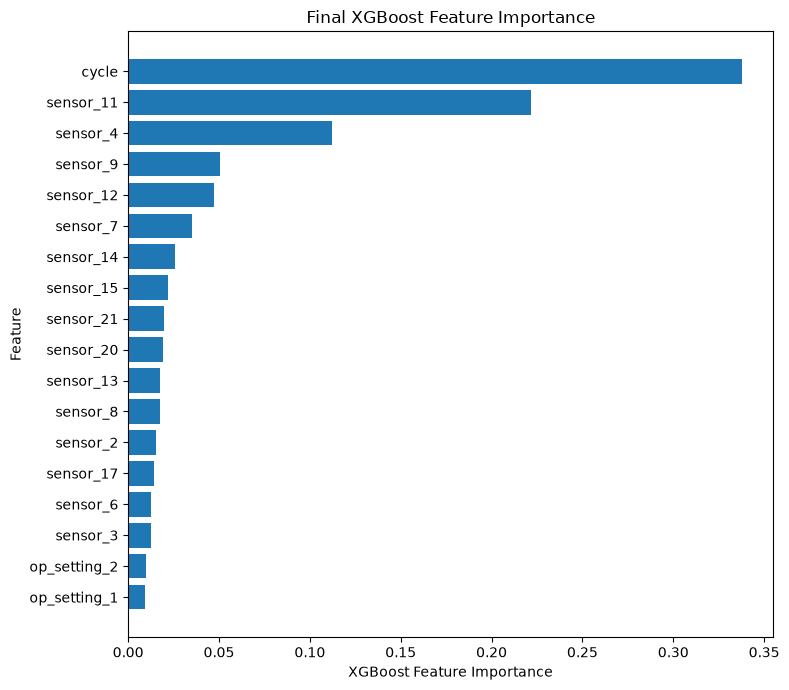

In [28]:
plt.figure(figsize=(8, 7))

plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("XGBoost Feature Importance")
plt.ylabel("Feature")
plt.title("Final XGBoost Feature Importance")

plt.tight_layout()

plt.savefig(
    "../reports/FD001/figures/final/Final_XGBoost_Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
importance_df.to_csv(
    "../reports/FD001/final_xgboost_feature_importance.csv",
    index=False
)

print("Saved final XGBoost feature importance.")

Saved final XGBoost feature importance.


## SHAP

In [30]:
explainer = shap.TreeExplainer(final_model)

shap_values = explainer.shap_values(
    X_train_final
)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (20631, 18)


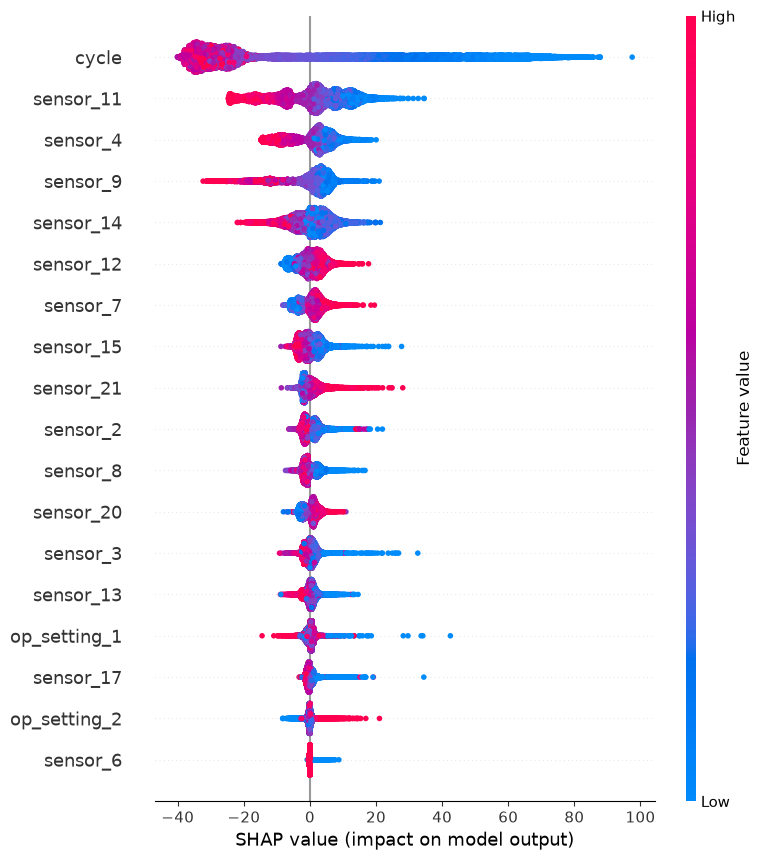

In [31]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_train_final,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../reports/FD001/figures/final/Final_XGBoost_SHAP_Summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

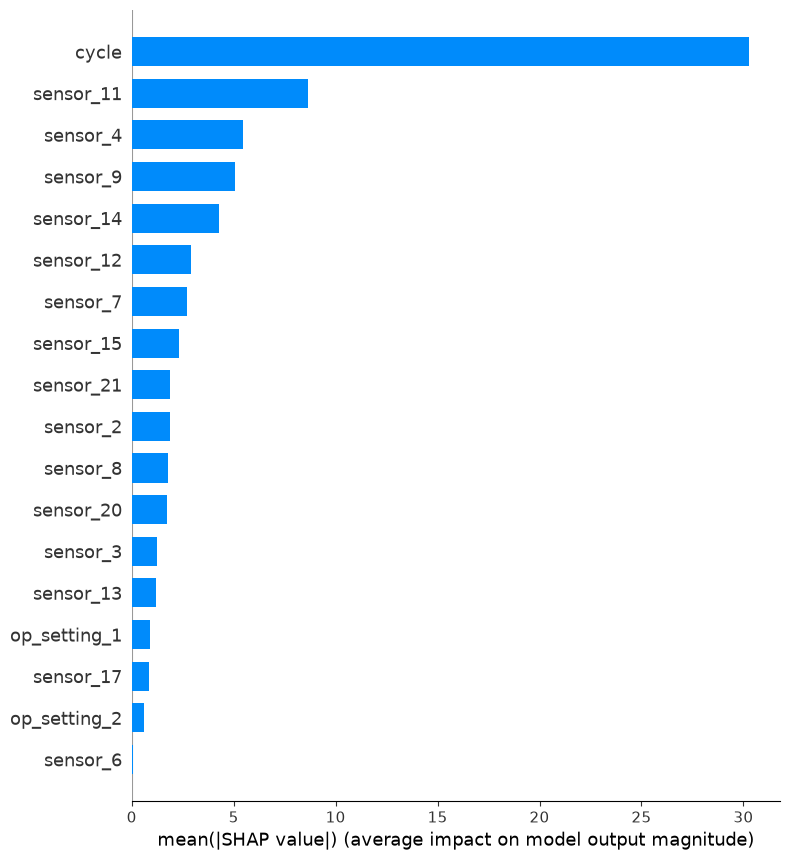

In [32]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_train_final,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig(
    "../reports/FD001/figures/final/Final_XGBoost_SHAP_Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
shap_importance = pd.DataFrame({
    "feature": feature_list,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "mean_abs_shap",
    ascending=False
).reset_index(drop=True)

display(shap_importance)

shap_importance.to_csv(
    "../reports/FD001/final_xgboost_shap_importance.csv",
    index=False
)

print("Saved SHAP importance.")

,feature,mean_abs_shap
0,cycle,30.279915
1,sensor_11,8.646894
2,sensor_4,5.445514
3,sensor_9,5.084323
4,sensor_14,4.286422
5,sensor_12,2.930534
6,sensor_7,2.705973
7,sensor_15,2.311092
8,sensor_21,1.900281
9,sensor_2,1.882357


Saved SHAP importance.


## Individual prediction explanation

In [34]:
test_raw = pd.read_csv(
    "../data/raw/FD001/test_FD001.txt",
    sep=r"\s+",
    header=None,
    names=[
        "unit",
        "cycle",
        "op_setting_1",
        "op_setting_2",
        "op_setting_3",
        "sensor_1",
        "sensor_2",
        "sensor_3",
        "sensor_4",
        "sensor_5",
        "sensor_6",
        "sensor_7",
        "sensor_8",
        "sensor_9",
        "sensor_10",
        "sensor_11",
        "sensor_12",
        "sensor_13",
        "sensor_14",
        "sensor_15",
        "sensor_16",
        "sensor_17",
        "sensor_18",
        "sensor_19",
        "sensor_20",
        "sensor_21"
    ]
)

test_last = (
    test_raw
    .sort_values(["unit", "cycle"])
    .groupby("unit")
    .tail(1)
    .sort_values("unit")
    .reset_index(drop=True)
)

X_test_last = test_last[feature_list].copy()

print("Final test observations:", X_test_last.shape)

Final test observations: (100, 18)


## First engine set prediction

In [35]:
engine_index = 0

engine_observation = X_test_last.iloc[[engine_index]]

engine_prediction = final_model.predict(
    engine_observation
)[0]

print("Engine:", test_last.iloc[engine_index]["unit"])
print("Cycle:", test_last.iloc[engine_index]["cycle"])
print("Predicted RUL:", round(engine_prediction, 3))

engine_shap_values = explainer(
    engine_observation
)

Engine: 1.0
Cycle: 31.0
Predicted RUL: 176.189


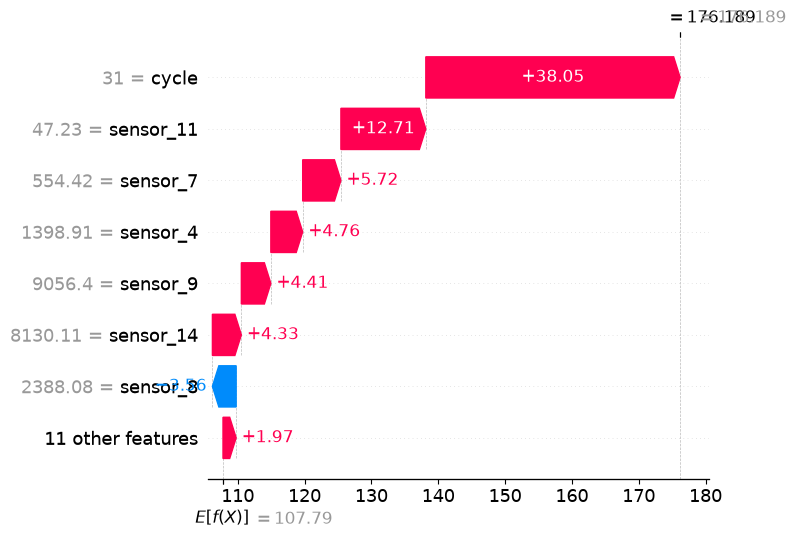

In [36]:
# Cleaner individual SHAP waterfall plot

engine_index = 0

engine_observation = X_test_last.iloc[[engine_index]]

engine_shap_values = explainer(
    engine_observation
)

plt.figure(figsize=(10, 8))

shap.plots.waterfall(
    engine_shap_values[0],
    max_display=8,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../reports/FD001/figures/final/Final_XGBoost_SHAP_Engine_1_Clean.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Summary

In [37]:
explainability_summary = pd.DataFrame({
    "analysis": [
        "Final XGBoost feature importance",
        "SHAP global importance",
        "Individual prediction explanation"
    ],
    "result": [
        "cycle and sensor_11 are the two most important features",
        "cycle has the largest average impact, followed by sensor_11, sensor_4 and sensor_9",
        "Engine 1 prediction is explained using SHAP contributions"
    ]
})

display(explainability_summary)

explainability_summary.to_csv(
    "../reports/FD001/explainability_summary.csv",
    index=False
)

print("Saved explainability summary.")

,analysis,result
0,Final XGBoost feature importance,cycle and sensor_11 are the two most important...
1,SHAP global importance,"cycle has the largest average impact, followed..."
2,Individual prediction explanation,Engine 1 prediction is explained using SHAP co...


Saved explainability summary.
